In [1]:
from collections import deque

graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': ['F'],
    'F': []
}

def bfs(graph, start):
    visited = set()
    queue = deque([start])

    while queue:
        node = queue.popleft()
        if node not in visited:
            print(node, end=" ")
            visited.add(node)
            queue.extend(graph[node])

def dfs(graph, node, visited=None):
    if visited is None:
        visited = set()

    if node not in visited:
        print(node, end=" ")
        visited.add(node)

        for neighbor in graph[node]:
            dfs(graph, neighbor, visited)

print("BFS Traversal:")
bfs(graph, 'A')

print("\nDFS Traversal:")
dfs(graph, 'A')

BFS Traversal:
A B C D E F 
DFS Traversal:
A B D E F C 

   Input Size  BFS Time  DFS Time
0        1000  0.000047  0.000017
1       40000  0.002062  0.000271
2       80000  0.004370  0.000664
3      200000  0.011533  0.002708
4     1000000  0.056164  0.013983


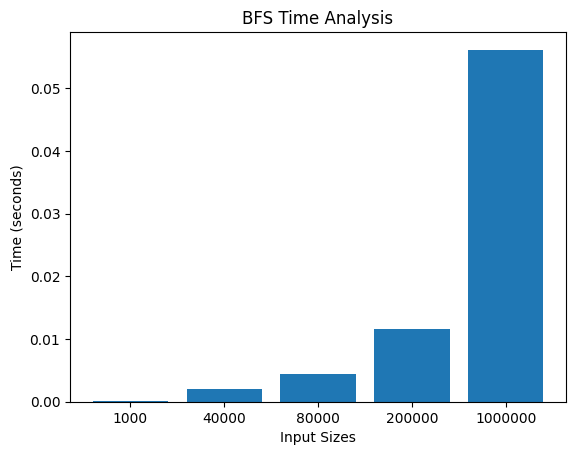

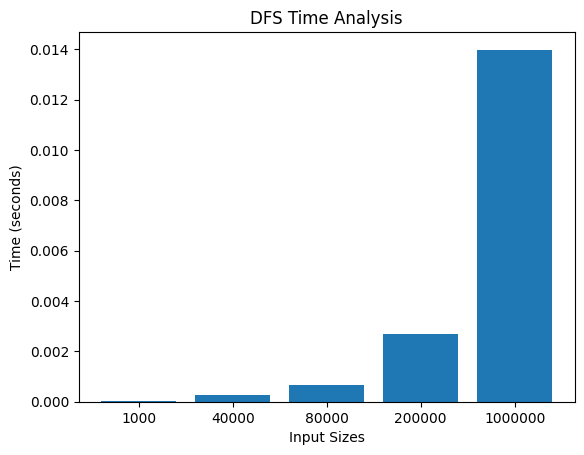

In [2]:
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

def bfs_search(lst, goal):
    queue = deque(lst)
    while queue:
        if queue.popleft() == goal:
            return True

def dfs_search(lst, goal):
    stack = lst.copy()
    while stack:
        if stack.pop() == goal:
            return True

sizes = [1000, 40000, 80000, 200000, 1000000]

bfs_times = []
dfs_times = []

for size in sizes:
    data = random.sample(range(size * 10), size)
    goal = data[len(data) - 220]

    start = time.time()
    bfs_search(data, goal)
    bfs_times.append(time.time() - start)

    start = time.time()
    dfs_search(data, goal)
    dfs_times.append(time.time() - start)

df = pd.DataFrame({
    "Input Size": sizes,
    "BFS Time": bfs_times,
    "DFS Time": dfs_times
})

print(df)

plt.bar(range(len(sizes)), bfs_times)
plt.xlabel("Input Sizes")
plt.ylabel("Time (seconds)")
plt.title("BFS Time Analysis")
plt.xticks(range(len(sizes)), sizes)
plt.show()

plt.bar(range(len(sizes)), dfs_times)
plt.xlabel("Input Sizes")
plt.ylabel("Time (seconds)")
plt.title("DFS Time Analysis")
plt.xticks(range(len(sizes)), sizes)
plt.show()

In [3]:
from collections import deque

graph = {
    "Islamabad": ["Rawalpindi", "Lahore", "Peshawar"],
    "Rawalpindi": ["Islamabad", "Peshawar", "Quetta"],
    "Peshawar": ["Islamabad", "Rawalpindi", "Quetta"],
    "Lahore": ["Islamabad", "Multan", "Quetta"],
    "Multan": ["Lahore", "Karachi", "Quetta"],
    "Quetta": ["Rawalpindi", "Peshawar", "Multan", "Karachi"],
    "Karachi": ["Multan", "Quetta"]
}

def bfs_shortest_path(graph, start, goal):
    queue = deque([[start]])
    visited = set()

    while queue:
        path = queue.popleft()
        node = path[-1]

        if node == goal:
            return path

        if node not in visited:
            visited.add(node)

            for neighbor in graph[node]:
                new_path = list(path)
                new_path.append(neighbor)
                queue.append(new_path)

path = bfs_shortest_path(graph, "Islamabad", "Karachi")
print("Shortest Path:", " -> ".join(path))

Shortest Path: Islamabad -> Rawalpindi -> Quetta -> Karachi
